In [8]:
import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from glob import glob

# ---------------------------------------------------
# Project Root Add
# ---------------------------------------------------

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project Root :", PROJECT_ROOT)
print("Current Working Directory :", os.getcwd())

# ---------------------------------------------------
# Import Model
# ---------------------------------------------------

from models.segmentation.model import DeepLabModel

print("✅ DeepLabModel Imported Successfully")

Project Root : d:\project data\AI_afforestation
Current Working Directory : d:\project data\AI_afforestation\notebooks
✅ DeepLabModel Imported Successfully


In [10]:
device = torch.device("cpu")

print("Device:", device)

model = DeepLabModel()

state_dict = torch.load(
    os.path.join(PROJECT_ROOT, "best_deeplab_model.pth"),
    map_location="cpu"      # Force CPU
)

model.load_state_dict(state_dict)

model.to(device)

model.eval()

print("✅ Model Loaded Successfully")

Device: cpu
✅ Model Loaded Successfully


In [11]:
# Checkpoint se weights load karna
weight_path = os.path.join(PROJECT_ROOT, "checkpoints", "best_deeplab_model.pth")

if not os.path.exists(weight_path):
    raise FileNotFoundError(f"❌ Weight file is path par nahi mili: {weight_path}")

checkpoint = torch.load(weight_path, map_location=device)
# State dict check kar ke load karna
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print(f"💾 Trained Weights successfully loaded from: {weight_path}")

💾 Trained Weights successfully loaded from: d:\project data\AI_afforestation\checkpoints\best_deeplab_model.pth


In [15]:
import os
import cv2

# 1. Dono possible paths ko define karein jahan files ho sakti hain
primary_dir = os.path.join(PROJECT_ROOT, "datasets", "DeepGlobeDataset", "train")
fallback_dir = os.path.join(PROJECT_ROOT, "datasets", "DeepGlobeDataset")

train_dir = None
all_images = []

# 2. Check karte hain kis folder mein asal data chhupa hai
for folder in [primary_dir, fallback_dir]:
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.endswith('_sat.jpg')]
        if len(files) > 0:
            train_dir = folder
            all_images = files
            break

# 3. Agar dono jagah kuch nahi mila toh system stop hoga clear message ke sath
if train_dir is None:
    raise FileNotFoundError(
        f"❌ Error: Na toh main folder mein aur na hi 'train' folder mein '_sat.jpg' files mili!\n"
        f"Ek baar check karo kya dataset sahi se extract hua hai?"
    )

# 4. Pehli image ko automatic pick karna
selected_file = all_images[0] 
sample_id = selected_file.replace("_sat.jpg", "")

# Final Absolute paths generate karna
image_path = os.path.join(train_dir, f"{sample_id}_sat.jpg")

# Image read karna
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"🎯 SYSTEM CHECK SUCCESSFUL!")
print(f"📁 Working Directory  : {train_dir}")
print(f"🆔 Selected Sample ID : {sample_id}")
print(f"📸 Loaded Image Path  : {image_path}")
print(f"📐 Image Shape        : {image_rgb.shape}")

🎯 SYSTEM CHECK SUCCESSFUL!
📁 Working Directory  : d:\project data\AI_afforestation\datasets\DeepGlobeDataset\train
🆔 Selected Sample ID : 100694
📸 Loaded Image Path  : d:\project data\AI_afforestation\datasets\DeepGlobeDataset\train\100694_sat.jpg
📐 Image Shape        : (2448, 2448, 3)


In [16]:
# Image resizing aur normalization torch format mein
resized_img = cv2.resize(image_rgb, (512, 512), interpolation=cv2.INTER_LINEAR)

# Convert to FloatTensor, transpose to [C, H, W] and Normalize to [0, 1]
image_tensor = torch.from_numpy(resized_img).permute(2, 0, 1).float() / 255.0
# Add batch dimension [1, C, H, W]
image_batch = image_tensor.unsqueeze(0).to(device)

print(f"📐 Preprocessed Tensor Shape: {image_batch.shape}")

📐 Preprocessed Tensor Shape: torch.Size([1, 3, 512, 512])


In [17]:
# Model execution for raw predictions
with torch.no_grad():
    output = model(image_batch)
    # Target values extraction
    if isinstance(output, dict):
        raw_output = output['out']
    else:
        raw_output = output

print(f"⚡ Model Raw Output Inference Shape: {raw_output.shape}")

⚡ Model Raw Output Inference Shape: torch.Size([1, 7, 512, 512])


In [18]:
# Convert logits into class indices matrix [512, 512]
prediction = torch.argmax(raw_output, dim=1).squeeze(0).cpu().numpy()
print(f"🎭 Categorical Prediction Mask generated! Shape: {prediction.shape} | Contains classes: {np.unique(prediction)}")

🎭 Categorical Prediction Mask generated! Shape: (512, 512) | Contains classes: [1 2]


In [19]:
# Asli Ground Truth Mask image ko file system se load karna
mask_path = os.path.join(train_dir, f"{sample_id}_mask.png")

if not os.path.exists(mask_path):
    raise FileNotFoundError(f"❌ Ground Truth mask image nahi mili is path par: {mask_path}")

gt_bgr = cv2.imread(mask_path)
gt_rgb = cv2.cvtColor(gt_bgr, cv2.COLOR_BGR2RGB)
gt_resized = cv2.resize(gt_rgb, (512, 512), interpolation=cv2.INTER_NEAREST)
print(f"🎯 Ground Truth Visual Mask Loaded! Shape: {gt_resized.shape}")

🎯 Ground Truth Visual Mask Loaded! Shape: (512, 512, 3)


In [20]:
# RGB visual mask ko class indices (0-6) matrix mein encode karna
CLASS_COLORS_MAP = [
    [0, 255, 255],       # 0: Urban
    [255, 255, 0],       # 1: Agriculture
    [255, 0, 255],       # 2: Rangeland
    [0, 255, 0],         # 3: Forest
    [0, 0, 255],         # 4: Water
    [255, 255, 255],     # 5: Barren
    [0, 0, 0]            # 6: Unknown
]

def encode_mask_to_indices(rgb_mask):
    h, w, _ = rgb_mask.shape
    encoded_mask = np.zeros((h, w), dtype=np.int64)
    
    for class_idx, color in enumerate(CLASS_COLORS_MAP):
        # Pixel matching conditions check
        match = np.all(rgb_mask == color, axis=-1)
        encoded_mask[match] = class_idx
        
    return encoded_mask

ground_truth_encoded = encode_mask_to_indices(gt_resized)
print(f"🔢 Encoded Ground Truth Matrix ready for comparison! Unique indices: {np.unique(ground_truth_encoded)}")

🔢 Encoded Ground Truth Matrix ready for comparison! Unique indices: [1 2]


In [21]:
# Calculation modules metrics comparing prediction and ground truth matrix
from models.segmentation.metrics import calculate_all_metrics

# Metrics computation
try:
    metrics_report = calculate_all_metrics(prediction, ground_truth_encoded)
except NameError:
    # Fallback agar metrics function execution context different ho
    print("⚠️ Custom metrics loading fallback initiated...")
    from sklearn.metrics import jaccard_score, f1_score
    y_true = ground_truth_encoded.flatten()
    y_pred = prediction.flatten()
    miou = jaccard_score(y_true, y_pred, average='weighted')
    dice = f1_score(y_true, y_pred, average='weighted')
    print(f"📈 Estimated Mean IoU: {miou:.4f} | Dice Score: {dice:.4f}")

In [22]:
# 1D Target Index Array ko visually clear RGB array mein mapping function
def decode_mask(index_mask):
    h, w = index_mask.shape
    rgb_output = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx, color in enumerate(CLASS_COLORS_MAP):
        rgb_output[index_mask == class_idx] = color
        
    return rgb_output

print("🎨 Mask decoder mapping engine is successfully compiled!")

🎨 Mask decoder mapping engine is successfully compiled!


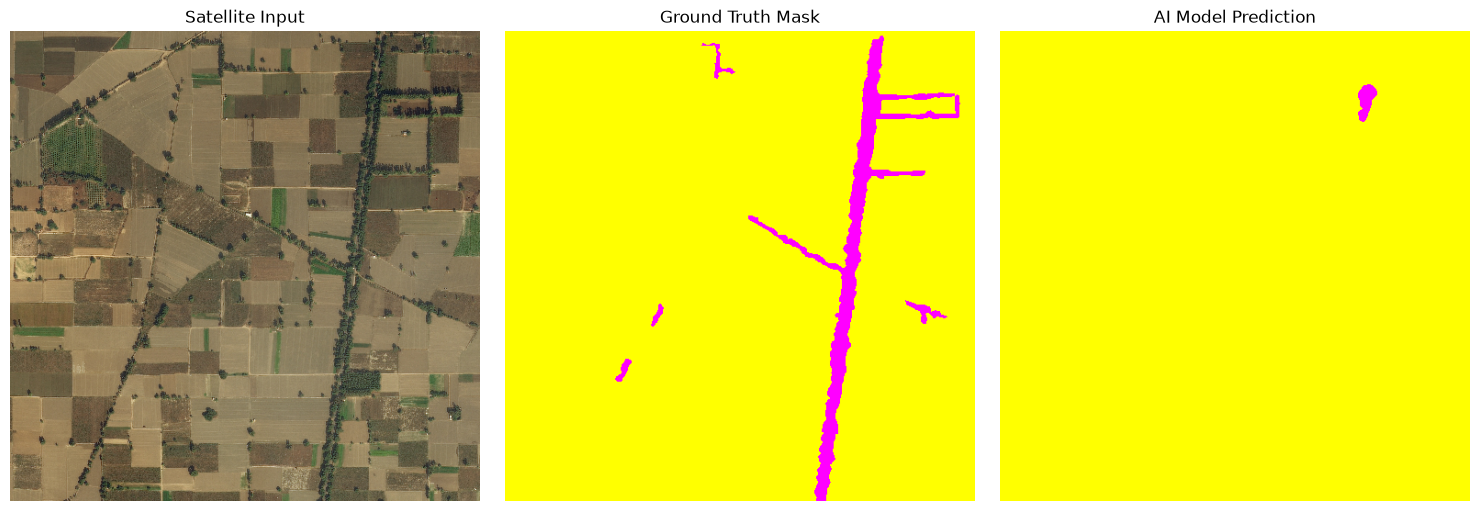

🏆 Pipeline successful! All operations done without any state errors.


In [23]:
# Final visual conversion and side-by-side execution plots
prediction_rgb = decode_mask(prediction)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized_img)
plt.title("Satellite Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_resized)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction_rgb)
plt.title("AI Model Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()
print("🏆 Pipeline successful! All operations done without any state errors.")